## Algerian Forest Fires Dataset

Data Set Information

The Dataset includes 244 instances that regroup a data of two regions of Algeria, namely the bajaia region located in northeast of Algeria. and the Sidi Bel-abbes region located in the northwest of algeria.

122 instances for each region.

The period from june 2012 to september 2012. The dataset includes 11 attributes and 1 output attribute (class) The 244 instances have been classified into fire (138 classes) and not fire (106 classes) classes.

Attribute Information: 

1. Date: (DD/MM/YYYY) Day, month(june to september), year 2012 wheather data observations.
2. Temp: Temperature noon (temperature max) in celcius degrees 22 to 42.
3. RH: Relative Humidity in % 21 to 90
4. Ws: Wind speed in km/h 6 to 29
5. Rain: total day in mm 0 to 16.8 FWI Compenents.
6. Fine fuel moisture code (FFMC) index from the FWI system 28.6 to 92.5
7. Duff Moisture Code (DMC) Index from the FWI system 1.1 to 65.9
8. Drought code (DC) Index from the FWI system 7 to 220.4
9. Initial Spread index (ISI) index from the FWI system 0 to 18.5   
10. Buildup index (BUI) index from the FWI system 1.1 to 68
11. Fire Weather Index (FWI) Index 0 to 31.1
12. classes: Two classes, namely fire and not fire

In [199]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [200]:
dataset = pd.read_csv('Algerian_forest_fires_dataset_UPDATE.csv',header=1)

In [201]:
dataset.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,01,06,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire
1,02,06,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire
2,03,06,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire
3,04,06,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire
4,05,06,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire


Notes: Here we are predicting Temperature so this is our dependant feature and all others are independant features

In [202]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 246 entries, 0 to 245
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   day          246 non-null    object
 1   month        245 non-null    object
 2   year         245 non-null    object
 3   Temperature  245 non-null    object
 4    RH          245 non-null    object
 5    Ws          245 non-null    object
 6   Rain         245 non-null    object
 7   FFMC         245 non-null    object
 8   DMC          245 non-null    object
 9   DC           245 non-null    object
 10  ISI          245 non-null    object
 11  BUI          245 non-null    object
 12  FWI          245 non-null    object
 13  Classes      244 non-null    object
dtypes: object(14)
memory usage: 27.0+ KB


In [203]:
## checking null/missing values

dataset[dataset.isnull().any(axis=1)]

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
122,Sidi-Bel Abbes Region Dataset,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
167,14,07,2012,37,37,18,0.2,88.9,12.9,14.6 9,12.5,10.4,fire,NaN


The dataset is converted into two sets based on region from 122 index, we can make a new column on the Region

1. "Bejaia Region Dataset"
2. "Sidi_Bel Abbes Dataset"

Add new column with region

In [204]:
dataset.loc[:122, 'Region'] = 0  # Assigning Region value 0 to rows 0 to 122 for Bejaia region
dataset.loc[123:, 'Region'] = 1  # Assigning Region value 1 to rows 123 onwards for Sidi-Bel region
df = dataset


In [205]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 246 entries, 0 to 245
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   day          246 non-null    object 
 1   month        245 non-null    object 
 2   year         245 non-null    object 
 3   Temperature  245 non-null    object 
 4    RH          245 non-null    object 
 5    Ws          245 non-null    object 
 6   Rain         245 non-null    object 
 7   FFMC         245 non-null    object 
 8   DMC          245 non-null    object 
 9   DC           245 non-null    object 
 10  ISI          245 non-null    object 
 11  BUI          245 non-null    object 
 12  FWI          245 non-null    object 
 13  Classes      244 non-null    object 
 14  Region       246 non-null    float64
dtypes: float64(1), object(14)
memory usage: 29.0+ KB


In [206]:
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,01,06,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0.0
1,02,06,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire,0.0
2,03,06,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0.0
3,04,06,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire,0.0
4,05,06,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire,0.0


In [207]:
df['Region'] = df['Region'].astype('int')

In [208]:
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,01,06,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,02,06,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire,0
2,03,06,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,04,06,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire,0
4,05,06,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire,0


In [209]:
df.isnull().sum()

day            0
month          1
year           1
Temperature    1
 RH            1
 Ws            1
Rain           1
FFMC           1
DMC            1
DC             1
ISI            1
BUI            1
FWI            1
Classes        2
Region         0
dtype: int64

In [210]:
## removing the null values
df = df.dropna().reset_index(drop=True)

In [211]:
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,01,06,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,02,06,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire,0
2,03,06,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,04,06,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire,0
4,05,06,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire,0


In [212]:
df.isnull().sum()

day            0
month          0
year           0
Temperature    0
 RH            0
 Ws            0
Rain           0
FFMC           0
DMC            0
DC             0
ISI            0
BUI            0
FWI            0
Classes        0
Region         0
dtype: int64

In [213]:
df.iloc[[122]]

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
122,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,1


Notes:
At row index 122, the column names are repeated as a data row. We need to drop this row to clean the dataset.

In [214]:
df = df.drop(122).reset_index(drop=True)

In [215]:
df.iloc[[122]]

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
122,01,06,2012,32,71,12,0.7,57.1,2.5,8.2,0.6,2.8,0.2,not fire,1


In [216]:
df.columns

Index(['day', 'month', 'year', 'Temperature', ' RH', ' Ws', 'Rain ', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes  ', 'Region'],
      dtype='object')

Notes:
The column names contain spaces, which can cause issues during data processing. To avoid this, we should remove the spaces and correct the column names.

In [217]:
## Fix spaces in column names
df.columns = df.columns.str.strip()
df.columns

Index(['day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes', 'Region'],
      dtype='object')

In [218]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243 entries, 0 to 242
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   day          243 non-null    object
 1   month        243 non-null    object
 2   year         243 non-null    object
 3   Temperature  243 non-null    object
 4   RH           243 non-null    object
 5   Ws           243 non-null    object
 6   Rain         243 non-null    object
 7   FFMC         243 non-null    object
 8   DMC          243 non-null    object
 9   DC           243 non-null    object
 10  ISI          243 non-null    object
 11  BUI          243 non-null    object
 12  FWI          243 non-null    object
 13  Classes      243 non-null    object
 14  Region       243 non-null    int64 
dtypes: int64(1), object(14)
memory usage: 28.6+ KB


### Changes the required columns as interger data type

In [219]:
df[['day', 'month', 'year', 'Temperature', 'RH', 'Ws']] = df[['day', 'month', 'year', 'Temperature', 'RH', 'Ws']].astype(int)

#### Changing the other columns to float data datatype

In [220]:
objects = [features for features in df.columns if df[features].dtypes=='O']

Notes:
Since the Classes column contains categorical data, we will perform one-hot encoding on it later. For now, let's convert the data type of all other columns from object to float, excluding the Classes column.

In [221]:
## converting object to float data types
for i in objects:
    if i !="Classes":
        df[i] = df[i].astype(float)

In [222]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243 entries, 0 to 242
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   day          243 non-null    int64  
 1   month        243 non-null    int64  
 2   year         243 non-null    int64  
 3   Temperature  243 non-null    int64  
 4   RH           243 non-null    int64  
 5   Ws           243 non-null    int64  
 6   Rain         243 non-null    float64
 7   FFMC         243 non-null    float64
 8   DMC          243 non-null    float64
 9   DC           243 non-null    float64
 10  ISI          243 non-null    float64
 11  BUI          243 non-null    float64
 12  FWI          243 non-null    float64
 13  Classes      243 non-null    object 
 14  Region       243 non-null    int64  
dtypes: float64(7), int64(7), object(1)
memory usage: 28.6+ KB


In [223]:
df.describe()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Region
count,243.000000,243.000000,243.0,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000
mean,15.761317,7.502058,2012.0,32.152263,62.041152,15.493827,0.762963,77.842387,14.680658,49.430864,4.742387,16.690535,7.035391,0.497942
std,8.842552,1.114793,0.0,3.628039,14.828160,2.811385,2.003207,14.349641,12.393040,47.665606,4.154234,14.228421,7.440568,0.501028
min,1.000000,6.000000,2012.0,22.000000,21.000000,6.000000,0.000000,28.600000,0.700000,6.900000,0.000000,1.100000,0.000000,0.000000
25%,8.000000,7.000000,2012.0,30.000000,52.500000,14.000000,0.000000,71.850000,5.800000,12.350000,1.400000,6.000000,0.700000,0.000000
50%,16.000000,8.000000,2012.0,32.000000,63.000000,15.000000,0.000000,83.300000,11.300000,33.100000,3.500000,12.400000,4.200000,0.000000
75%,23.000000,8.000000,2012.0,35.000000,73.500000,17.000000,0.500000,88.300000,20.800000,69.100000,7.250000,22.650000,11.450000,1.000000
max,31.000000,9.000000,2012.0,42.000000,90.000000,29.000000,16.800000,96.000000,65.900000,220.400000,19.000000,68.000000,31.100000,1.000000


In [224]:
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [225]:
## lets save this cleaned the dataset into csv file

df.to_csv('Algerian_forest_fires_dataset_Cleaned.csv',index=False)

### Lets Do EDA on Dataset

Notes:
Since we are predicting Temperature, the Date column is unlikely to contribute significantly to the prediction. Therefore, we will remove it from the dataset.

In [226]:
## drop day,month,year columns as we don't need them
df_copy = df.drop(['day','month','year'],axis=1)

In [227]:
df_copy.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [228]:
## Check categories in Classes column
df_copy['Classes'].value_counts()

Classes
fire             131
not fire         101
fire               4
fire               2
not fire           2
not fire           1
not fire           1
not fire           1
Name: count, dtype: int64

In [229]:
## Encoding of the categories in classes
df_copy["Classes"]  = np.where(df_copy['Classes'].str.contains("not fire"),0,1)

Notes:
As the Classes column contains categorical data, we encoded it by assigning 0 to "not fire" entries and 1 to all other values using binary encoding

In [230]:
df_copy.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,0,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,0,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,0,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,0,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,0,0


In [231]:
df_copy.tail()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
238,30,65,14,0.0,85.4,16.0,44.5,4.5,16.9,6.5,1,1
239,28,87,15,4.4,41.1,6.5,8.0,0.1,6.2,0.0,0,1
240,27,87,29,0.5,45.9,3.5,7.9,0.4,3.4,0.2,0,1
241,24,54,18,0.1,79.7,4.3,15.2,1.7,5.1,0.7,0,1
242,24,64,15,0.2,67.3,3.8,16.5,1.2,4.8,0.5,0,1


In [232]:
df_copy['Classes'].value_counts()

Classes
1    137
0    106
Name: count, dtype: int64

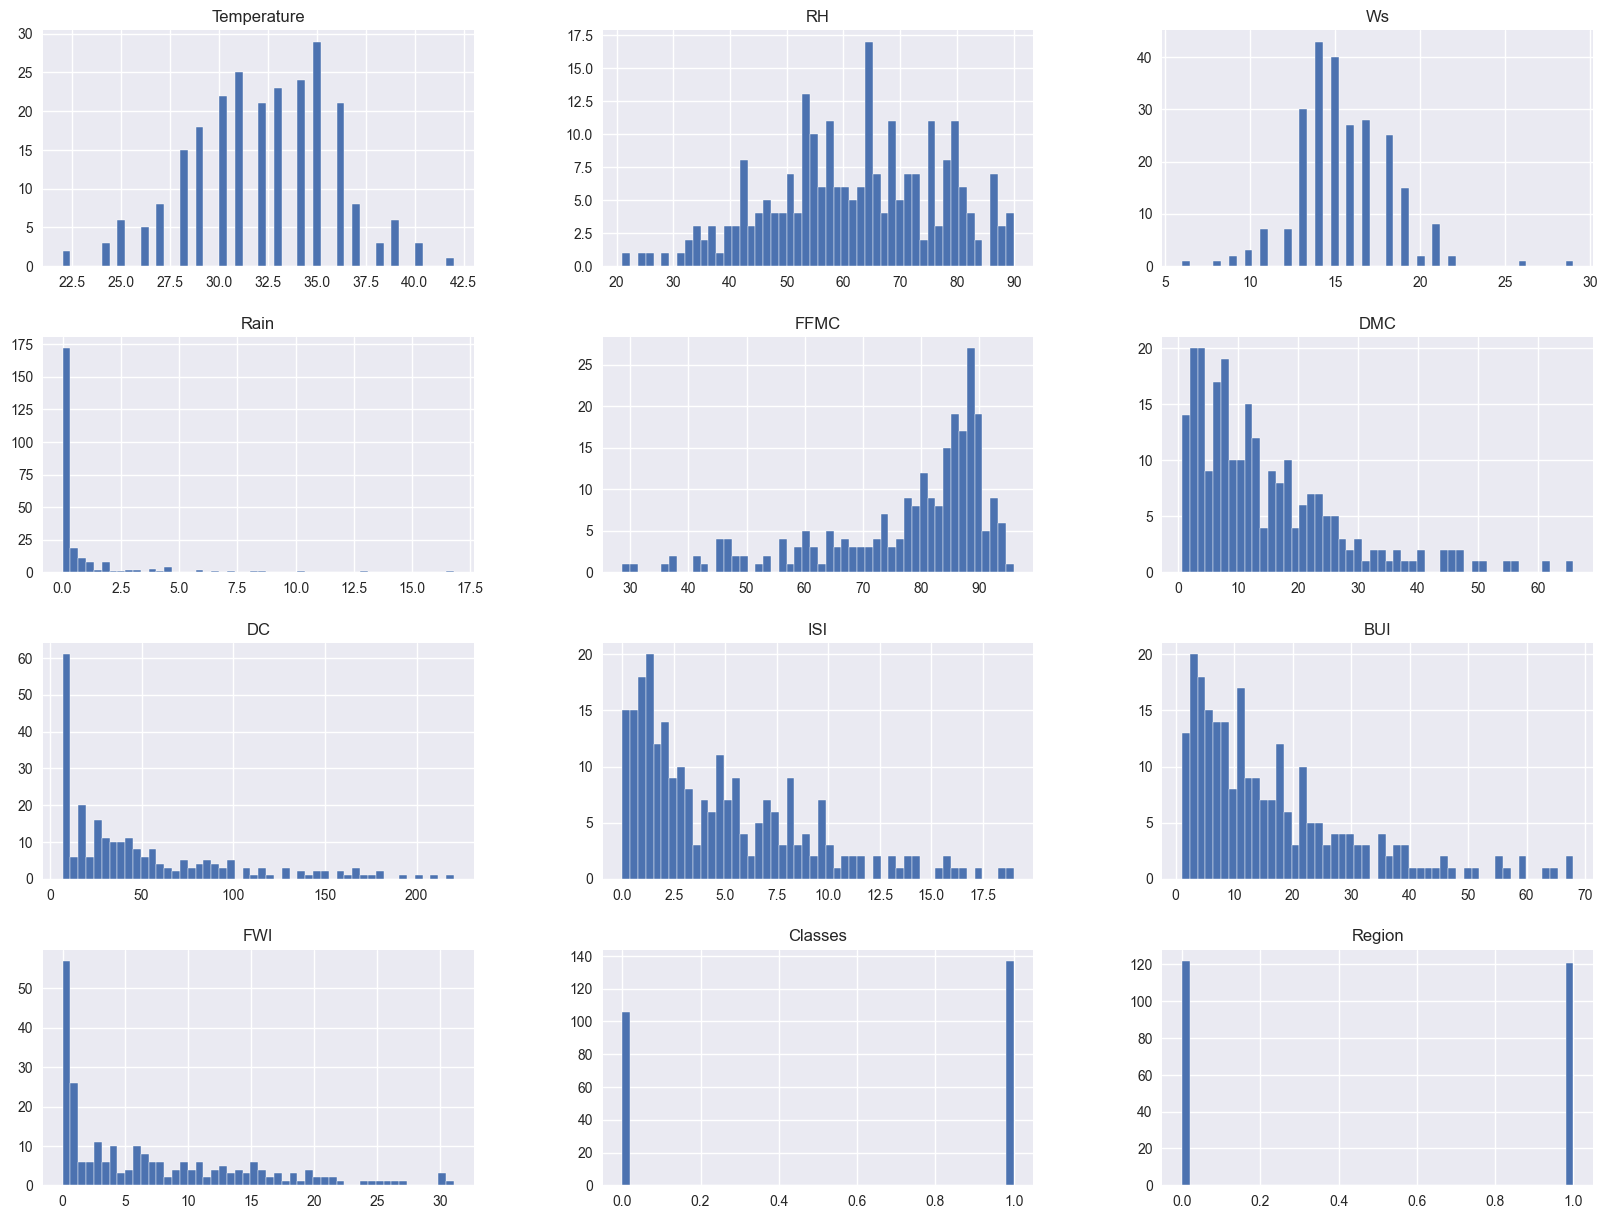

In [233]:
## Plot Density plot for all features

plt.style.use('seaborn-v0_8')
df_copy.hist(bins=50,figsize=(20,15))
plt.show()

### Notes on Feature Distribution (Histogram Analysis)
- Temperature, RH, Ws: 
Appear to follow a relatively normal distribution, which is favorable for many algorithms.

- Rain, DC, ISI, FWI, DMC, BUI:
These features are right-skewed, indicating that most values are concentrated on the lower end, with a few high outliers.

- FFMC:
Shows a bimodal distribution, suggesting two separate patterns or groupings.

- Classes and Region:
Both are binary features, clearly showing two distinct categories.

In [234]:
## percentage for pie chart 
percentage = df_copy['Classes'].value_counts(normalize=True)*100

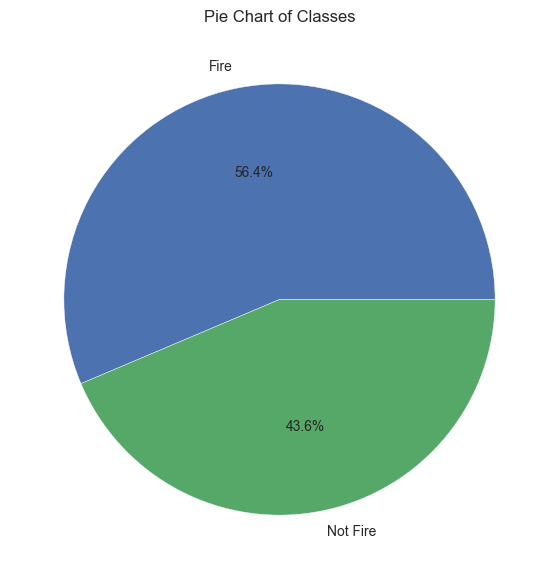

In [235]:
## plotting piechart

classlables = ['Fire',"Not Fire"]
plt.figure(figsize=(12,7))
plt.pie(percentage,labels=classlables,autopct='%1.1f%%')
plt.title("Pie Chart of Classes")
plt.show()

In [236]:
## lets check correlation 
df_copy.corr()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
Temperature,1.000000,-0.651400,-0.284510,-0.326492,0.676568,0.485687,0.376284,0.603871,0.459789,0.566670,0.516015,0.269555
RH,-0.651400,1.000000,0.244048,0.222356,-0.644873,-0.408519,-0.226941,-0.686667,-0.353841,-0.580957,-0.432161,-0.402682
Ws,-0.284510,0.244048,1.000000,0.171506,-0.166548,-0.000721,0.079135,0.008532,0.031438,0.032368,-0.069964,-0.181160
Rain,-0.326492,0.222356,0.171506,1.000000,-0.543906,-0.288773,-0.298023,-0.347484,-0.299852,-0.324422,-0.379097,-0.040013
FFMC,0.676568,-0.644873,-0.166548,-0.543906,1.000000,0.603608,0.507397,0.740007,0.592011,0.691132,0.769492,0.222241
DMC,0.485687,-0.408519,-0.000721,-0.288773,0.603608,1.000000,0.875925,0.680454,0.982248,0.875864,0.585658,0.192089
DC,0.376284,-0.226941,0.079135,-0.298023,0.507397,0.875925,1.000000,0.508643,0.941988,0.739521,0.511123,-0.078734
ISI,0.603871,-0.686667,0.008532,-0.347484,0.740007,0.680454,0.508643,1.000000,0.644093,0.922895,0.735197,0.263197
BUI,0.459789,-0.353841,0.031438,-0.299852,0.592011,0.982248,0.941988,0.644093,1.000000,0.857973,0.586639,0.089408
FWI,0.566670,-0.580957,0.032368,-0.324422,0.691132,0.875864,0.739521,0.922895,0.857973,1.000000,0.719216,0.197102


<Axes: >

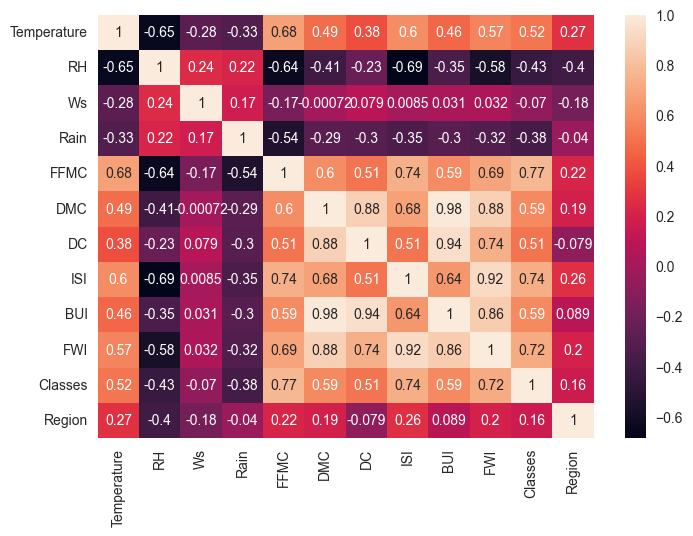

In [237]:
## lets see correlation in the heatmap
sns.heatmap(df_copy.corr(),annot=True)

<Axes: ylabel='FWI'>

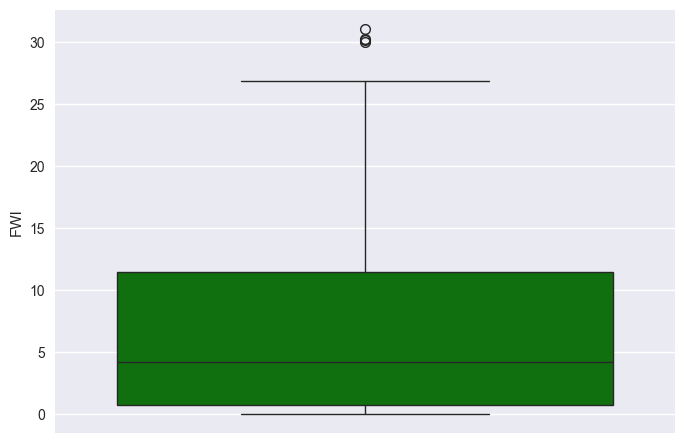

In [238]:
## lets see the feature in the form of boxplot

sns.boxplot(df['FWI'],color='green')

In [239]:
df_copy

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,0,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,0,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,0,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,0,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
238,30,65,14,0.0,85.4,16.0,44.5,4.5,16.9,6.5,1,1
239,28,87,15,4.4,41.1,6.5,8.0,0.1,6.2,0.0,0,1
240,27,87,29,0.5,45.9,3.5,7.9,0.4,3.4,0.2,0,1
241,24,54,18,0.1,79.7,4.3,15.2,1.7,5.1,0.7,0,1


In [240]:
df['Classes'] = np.where(df['Classes'].str.contains('not fire'),'not fire','fire')

Text(0.5, 1.0, 'Fire Analysis of Sidi -Bel Region')

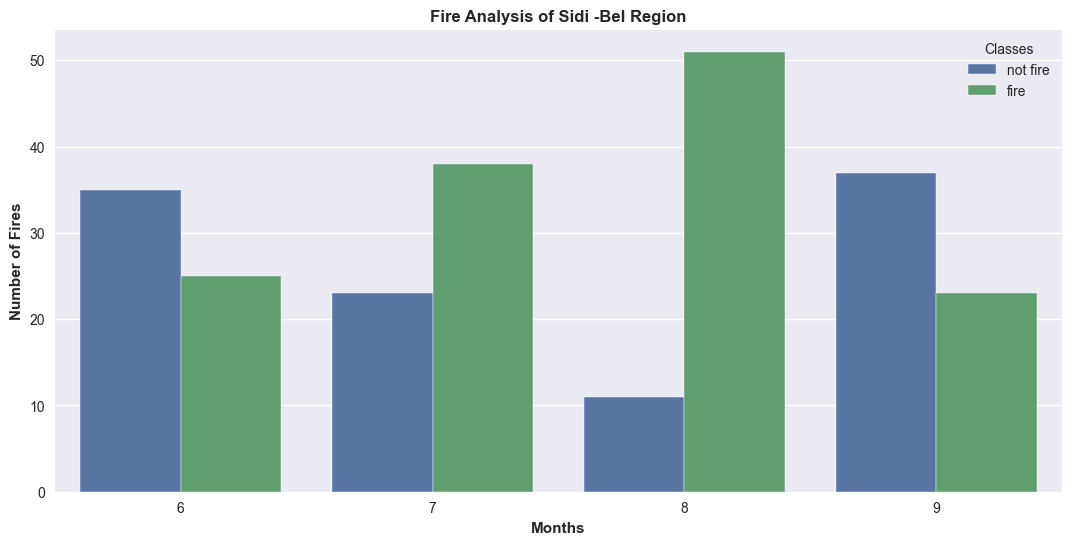

In [241]:
## Monthly Fire Analysis

dftemp = df.loc[df['Region']==1]
plt.subplots(figsize=(13,6))
sns.set_style('whitegrid')
sns.countplot(x='month',hue='Classes',data=df)
plt.ylabel("Number of Fires",weight='bold')
plt.xlabel('Months',weight='bold')
plt.title("Fire Analysis of Sidi -Bel Region",weight='bold')

Text(0.5, 1.0, 'Fire Analysis of Bejaia Region')

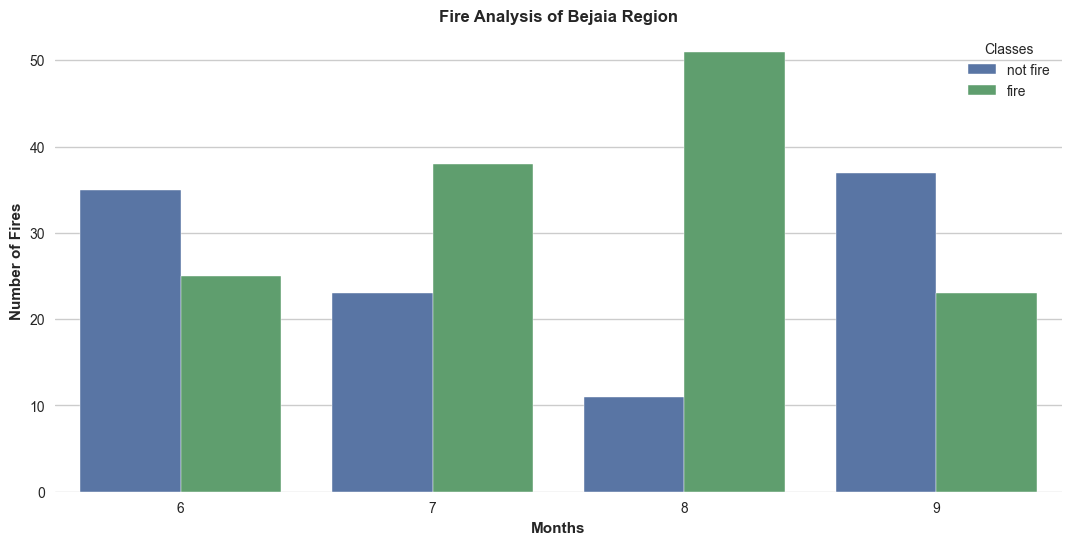

In [242]:
## Monthly Fire Analysis

dftemp = df.loc[df['Region']==0]
plt.subplots(figsize=(13,6))
sns.set_style('whitegrid')
sns.countplot(x='month',hue='Classes',data=df)
plt.ylabel("Number of Fires",weight='bold')
plt.xlabel('Months',weight='bold')
plt.title("Fire Analysis of Bejaia Region",weight='bold')

### Observation:

its observered that August and September had most number of forest fires for both regions.And from the above plot of months, we can understand few things.

Most of the fires happened in August and very high Fires happened in only 3 months - Jun,July and August.

Less fire was in September.

# Model Training

In [243]:
df_copy.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,0,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,0,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,0,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,0,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,0,0


#### Lets create Dependant and Independant Features

In [244]:
## independant and dependant features
X = df_copy.drop('FWI',axis=1)
y = df_copy['FWI']

In [245]:
X.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0,0


In [246]:
y.head()

0    0.5
1    0.4
2    0.1
3    0.0
4    0.5
Name: FWI, dtype: float64

- Above we have stored all independant features in X variable, and Dependant feature in y variable

#### Lets do Train Test Split for model training

In [247]:
## Train Test split 
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=42)

In [248]:
X_train.shape,X_test.shape

((182, 11), (61, 11))

In [249]:
y_train.shape,y_test.shape

((182,), (61,))

In [250]:
## Feature selection based on correlation
X_train.corr()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,Region
Temperature,1.000000,-0.656095,-0.305977,-0.317512,0.694768,0.498173,0.390684,0.629848,0.473609,0.542141,0.254549
RH,-0.656095,1.000000,0.225736,0.241656,-0.653023,-0.414601,-0.236078,-0.717804,-0.362317,-0.456876,-0.394665
Ws,-0.305977,0.225736,1.000000,0.251932,-0.190076,0.000379,0.096576,-0.023558,0.035633,-0.082570,-0.199969
Rain,-0.317512,0.241656,0.251932,1.000000,-0.545491,-0.289754,-0.302341,-0.345707,-0.300964,-0.369357,-0.059022
FFMC,0.694768,-0.653023,-0.190076,-0.545491,1.000000,0.620807,0.524101,0.750799,0.607210,0.781259,0.249514
DMC,0.498173,-0.414601,0.000379,-0.289754,0.620807,1.000000,0.868647,0.685656,0.983175,0.617273,0.212582
DC,0.390684,-0.236078,0.096576,-0.302341,0.524101,0.868647,1.000000,0.513701,0.942414,0.543581,-0.060838
ISI,0.629848,-0.717804,-0.023558,-0.345707,0.750799,0.685656,0.513701,1.000000,0.643818,0.742977,0.296441
BUI,0.473609,-0.362317,0.035633,-0.300964,0.607210,0.983175,0.942414,0.643818,1.000000,0.612239,0.114897
Classes,0.542141,-0.456876,-0.082570,-0.369357,0.781259,0.617273,0.543581,0.742977,0.612239,1.000000,0.188837


Notes:

Some of the independent features are highly correlated, which may lead to multicollinearity issues. To address this, we are removing those variables whose pairwise correlation exceeds a threshold of 0.85.

In [251]:
def correlation(dataset,threshold):
    col_corr = set()
    corr_metrix = dataset.corr()
    for i in range(len(corr_metrix.columns)):
        for j in range(i):
            if abs(corr_metrix.iloc[i,j])>threshold:
                colname = corr_metrix.columns[i]
                col_corr.add(colname)
    return col_corr

In [252]:
## Threshold --- Domain Expertise

corr_features = correlation(X_train,0.85)

In [253]:
## lets see correalted features
corr_features

{'BUI', 'DC'}

Notes:

As we can see, the features {'BUI', 'DC'} have high correlations with several other variables. Therefore, we are dropping them to reduce multicollinearity in the model.

In [254]:
## drop features when correlation is more than 0.85

X_train.drop(corr_features,axis=1,inplace=True)
X_test.drop(corr_features,axis=1,inplace=True)
X_train.shape,X_test.shape

((182, 9), (61, 9))

As we know, having all independent features on the same scale helps the model train more effectively. Therefore, we apply feature scaling (standardization) to ensure that each feature contributes equally during model training.

## Feature Scalling Or Standardization

In [255]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [256]:
X_train_scaled

array([[-0.84284248,  0.78307967,  1.29972026, ..., -0.62963326,
        -1.10431526, -0.98907071],
       [-0.30175842,  0.64950844, -0.59874754, ..., -0.93058524,
        -1.10431526,  1.01105006],
       [ 2.13311985, -2.08870172, -0.21905398, ...,  2.7271388 ,
         0.90553851,  1.01105006],
       ...,
       [-1.9250106 ,  0.9166509 ,  0.54033314, ..., -1.06948615,
        -1.10431526, -0.98907071],
       [ 0.50986767, -0.21870454,  0.16063958, ...,  0.5973248 ,
         0.90553851,  1.01105006],
       [-0.57230045,  0.98343651,  2.05910739, ..., -0.86113478,
        -1.10431526, -0.98907071]], shape=(182, 9))

Notes:
Now, let's visualize the scaled data using a box plot to understand the effect of the StandardScaler.

Text(0.5, 1.0, 'X_train Data after scalling')

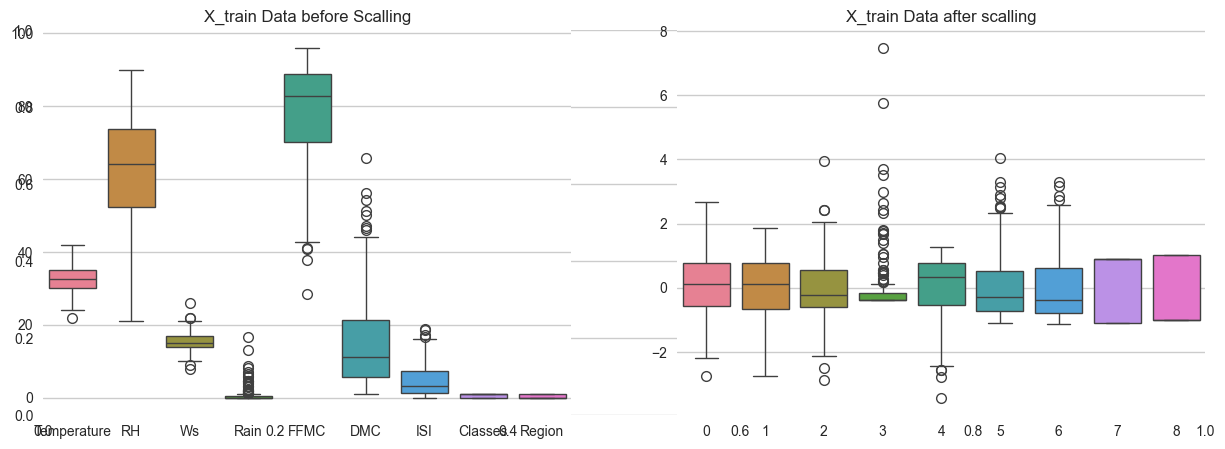

In [257]:
### Box plots to Understand Effect of standard

plt.subplots(figsize=(15,5))
plt.subplot(1,2,1)
sns.boxplot(data=X_train)
plt.title("X_train Data before Scalling")
plt.subplot(1,2,2)
sns.boxplot(data=X_train_scaled)
plt.title("X_train Data after scalling")


## Training a Model 
### Linear Regression Model 

In [258]:
X_train_scaled.shape,X_test.shape

((182, 9), (61, 9))

In [259]:
y_train.shape,y_test.shape

((182,), (61,))

Mean Absolute Error 0.5468236465249978
R2 score 0.9847657384266951


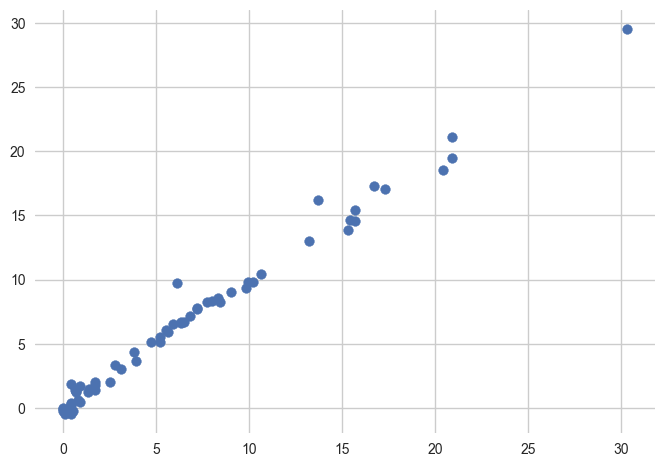

In [260]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

linereg = LinearRegression()
linereg.fit(X_train_scaled,y_train)
y_pred = linereg.predict(X_test_scaled)
mae = mean_absolute_error(y_test,y_pred)
score = r2_score(y_test,y_pred)
print("Mean Absolute Error",mae)
print("R2 score",score)
plt.scatter(y_test,y_pred)

##### Notes : 
R² Score: 0.9848 → Model explains 98.5% of target variance (excellent fit).

MAE: 0.547 → Very low average error.

Scatter Plot → Predictions closely match actual values (points near diagonal).

✅ Conclusion: Model is performing very well and is suitable for deployment or further testing.

# Lets try with Lasso Regression

Why We Use Lasso Regression
Lasso Regression (Least Absolute Shrinkage and Selection Operator) is used primarily for:

🔍 Feature Selection: It can shrink less important feature coefficients exactly to zero, effectively removing them from the model.

📉 Preventing Overfitting: Adds L1 regularization, which penalizes large coefficients and helps generalize better on unseen data.

🧹 Handling Multicollinearity: Useful when independent variables are highly correlated, as it tends to keep one and discard others.

Mean Absolute Error 1.133175994914409
R2 score 0.9492020263112388


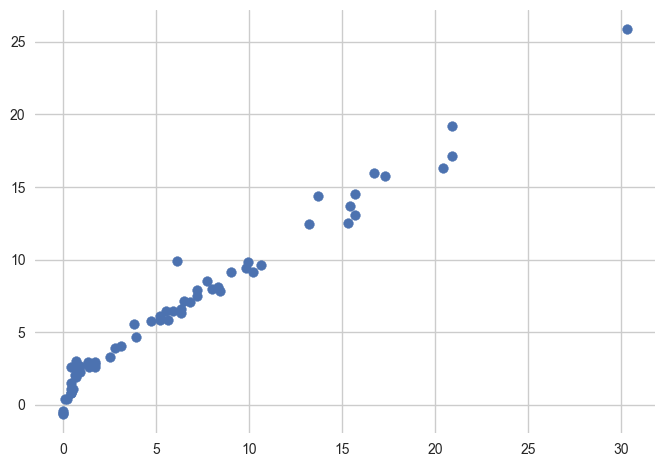

In [261]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
lasso = Lasso()
lasso.fit(X_train_scaled,y_train)
y_pred = lasso.predict(X_test_scaled)
mae = mean_absolute_error(y_test,y_pred)
score = r2_score(y_test,y_pred)
print("Mean Absolute Error",mae)
print("R2 score",score)
plt.scatter(y_test,y_pred)

### Notes:

Mean Absolute Error (MAE): 1.1332
→ Moderate prediction error; higher than previous models.

R² Score: 0.9492
→ Model explains 94.9% of the variance in the target variable, which is very good, though slightly less than other models tried.

✅ Conclusion:
The Lasso model performs well, with strong predictive ability.

#### Cross validation with Lasso

In [273]:
from sklearn.linear_model import LassoCV
lassocv = LassoCV(cv=5)
lassocv.fit(X_train_scaled,y_train)

LassoCV(cv=5)

Mean absolute Erro 0.619970115826343
R2 score 0.9820946715928275


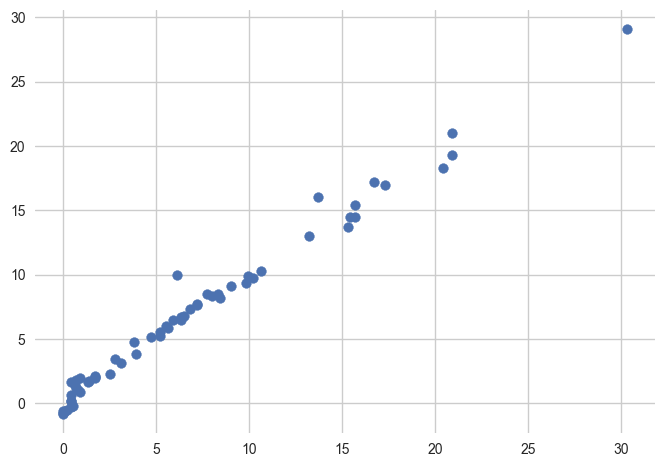

In [274]:
y_pred = lassocv.predict(X_test_scaled)
plt.scatter(y_test,y_pred)
mae= mean_absolute_error(y_test,y_pred)
score = r2_score(y_test,y_pred)
print("Mean absolute Erro",mae)
print("R2 score",score)


### Notes:

Mean Absolute Error (MAE): 0.6199
→ Indicates the model's average prediction error is low.

R² Score: 0.9821
→ Suggests the model explains 98.2% of the variance in the target variable, showing excellent predictive performance.

Conclusion:
LassoCV not only performs well but also helps in automatic feature selection by shrinking irrelevant feature coefficients.
This results in a simpler, more interpretable model with high accuracy.

## Lets see with Ridge Regression model

Mean Absolute Error 0.5642305340105715
R2 score 0.9842993364555512


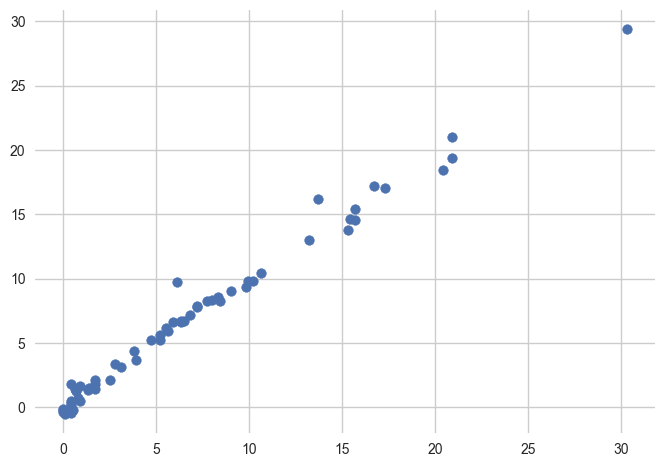

In [276]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
ridge = Ridge()
ridge.fit(X_train_scaled,y_train)
y_pred = ridge.predict(X_test_scaled)
mae = mean_absolute_error(y_test,y_pred)
score = r2_score(y_test,y_pred)
print("Mean Absolute Error",mae)
print("R2 score",score)
plt.scatter(y_test,y_pred)

### Notes:

Mean Absolute Error (MAE): 0.5642
→ Very low prediction error, indicating accurate predictions.

R² Score: 0.9843
→ Model explains 98.4% of the variance in the target variable, showing excellent fit.

✅ Conclusion:
The Ridge Regression model performs exceptionally well, similar to LassoCV and better than basic Lasso.

It's especially effective when all features are relevant and multicollinearity is present, as it shrinks coefficients without eliminating features.

A great choice when you want high performance without dropping any variables.



Mean absolute Erro 0.5642305340105715
R2 score 0.9842993364555512


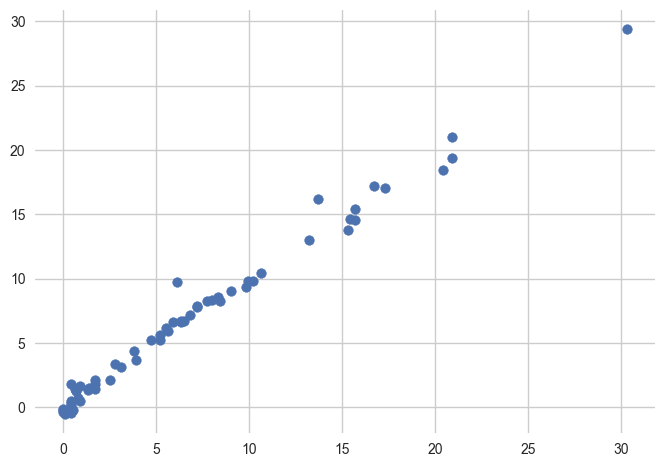

In [277]:
from sklearn.linear_model import RidgeCV
ridgecv = RidgeCV(cv=5)
ridgecv.fit(X_train_scaled,y_train)
y_pred = ridgecv.predict(X_test_scaled)
plt.scatter(y_test,y_pred)
mae= mean_absolute_error(y_test,y_pred)
score = r2_score(y_test,y_pred)
print("Mean absolute Erro",mae)
print("R2 score",score)


### Notes:
Mean Absolute Error (MAE): 0.5642
→ Very low error, indicating strong prediction accuracy.

R² Score: 0.9843
→ The model explains 98.4% of the variance, which is excellent.

✅ Conclusion:
RidgeCV with cross-validation delivers robust and stable performance, ensuring the best regularization strength is chosen automatically.

The model generalizes well and handles multicollinearity effectively without removing features.

It is a reliable choice when you want high accuracy along with model stability across folds.

## Lets check with ElasticNet Regression

Mean Absolute Error 1.8822353634896005
R2 score 0.8753460589519703


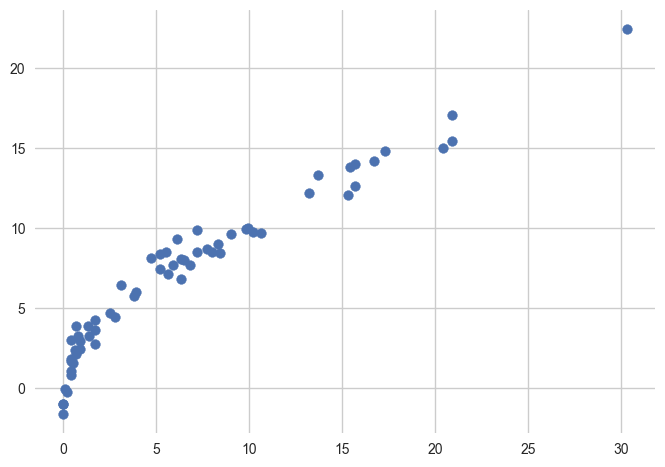

In [278]:
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
elasticnet = ElasticNet()
elasticnet.fit(X_train_scaled,y_train)
y_pred = elasticnet.predict(X_test_scaled)
mae = mean_absolute_error(y_test,y_pred)
score = r2_score(y_test,y_pred)
print("Mean Absolute Error",mae)
print("R2 score",score)
plt.scatter(y_test,y_pred)

### Notes
Mean Absolute Error (MAE): 1.88
→ The model has a moderate error, indicating that there is room for improvement, but still reasonable prediction accuracy.

R² Score: 0.8753
→ The model explains 87.5% of the variance, which is quite strong, showing that the model is able to capture the relationship between the input features and the target variable effectively.

✅ Conclusion:
ElasticNet performs well with an R² score of 0.8753, indicating that it explains a substantial amount of variance in the data. While the MAE of 1.88 suggests that there is still some error in predictions, it remains a solid result for most practical applications.

ElasticNet provides a balance between Lasso and Ridge regression by performing both L1 and L2 regularization, which helps in handling multicollinearity and feature selection effectively. It is a reliable model when you want to manage overfitting and improve the generalization of the model.

ElasticNet is suitable for cases where you suspect both irrelevant features and multicollinearity, offering a balanced trade-off between prediction accuracy and interpretability.

Mean absolute Erro 0.6575946731430898
R2 score 0.9814217587854941


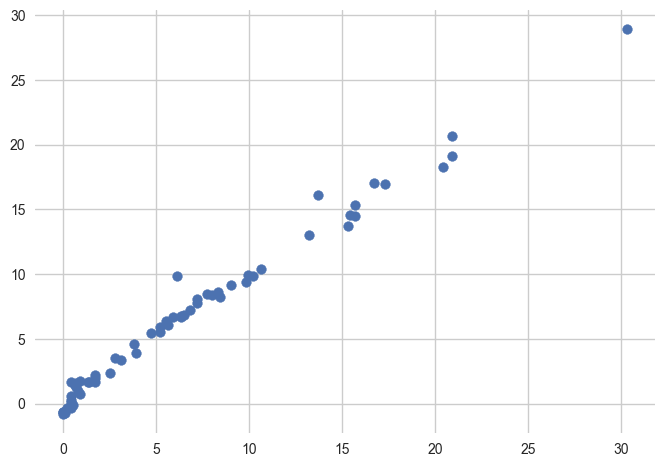

In [279]:
from sklearn.linear_model import ElasticNetCV
elasticnetcv = ElasticNetCV(cv=5)
elasticnetcv.fit(X_train_scaled,y_train)
y_pred = elasticnetcv.predict(X_test_scaled)
plt.scatter(y_test,y_pred)
mae= mean_absolute_error(y_test,y_pred)
score = r2_score(y_test,y_pred)
print("Mean absolute Erro",mae)
print("R2 score",score)


### Notes: 
Mean Absolute Error (MAE): 0.6576
→ The model has a very low MAE, indicating excellent prediction accuracy. The average deviation from the actual values is small, making this model quite reliable.

R² Score: 0.9814
→ The model explains 98.1% of the variance in the target variable, which is outstanding. A high R² score means the model fits the data very well and can predict the target variable effectively.

✅ Conclusion:
ElasticNetCV with 5-fold cross-validation performs exceptionally well with an R² score of 0.9814, explaining the vast majority (98.1%) of the variance in the target variable. The MAE of 0.6576 further reinforces the model's accuracy, showing minimal prediction error.

The 5-fold cross-validation process ensures that the model is stable and generalizes well across different subsets of the data, providing reliable results and automatically tuning the regularization strength.

ElasticNetCV, combining L1 and L2 regularization, is a great choice for datasets where you suspect both irrelevant features and multicollinearity. The model strikes an excellent balance between feature selection and avoiding overfitting, making it highly suitable for high-accuracy tasks where generalization is important.

ElasticNetCV is a top performer for problems requiring robustness, feature selection, and strong predictive power.

## lets Dump/deploy/pickle the Best model as here we are pickling Ridge model

In [280]:
## Pickle the machine learning models, preprocessing model standardscaler

scaler

StandardScaler()

In [282]:
ridge

Ridge()

In [283]:
import pickle

pickle.dump(scaler,open('scaler.pkl','wb'))
pickle.dump(ridge,open('ridge.pkl','wb'))

